In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
logreg = pd.read_csv("../results/tuning/logreg.csv")
svm = pd.read_csv("../results/tuning/svm.csv")
rf = pd.read_csv("../results/tuning/rf.csv")
knn = pd.read_csv("../results/tuning/knn.csv")

In [65]:
knn

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.130240,0.013389,1.278978,0.153865,3,{'clf__n_neighbors': 3},0.708703,0.703927,0.700835,0.702444,0.704759,0.704134,0.002648,1
1,0.113048,0.013387,1.233857,0.130028,5,{'clf__n_neighbors': 5},0.694028,0.682440,0.686090,0.686417,0.688372,0.687469,0.003798,2
2,0.106700,0.018516,1.380263,0.069675,7,{'clf__n_neighbors': 7},0.683232,0.668631,0.673198,0.672208,0.674946,0.674443,0.004854,3


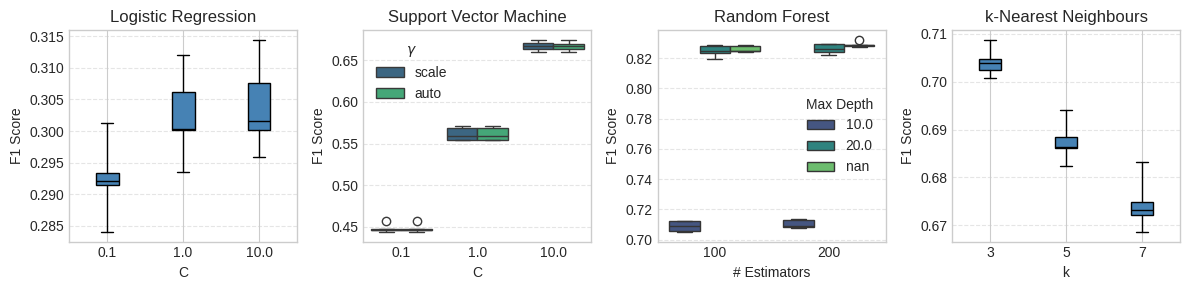

In [84]:
_, axs = plt.subplots(1, 4, figsize=(12, 3))

HUE_PALETTE = "viridis"
SINGLE_COLOR = "steelblue"
MEDIAN_COLOR = "black"

splits = [
    "split0_test_score",
    "split1_test_score",
    "split2_test_score",
    "split3_test_score",
    "split4_test_score"
]

for ax in axs:
    ax.set_ylabel("F1 Score")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

axs[0].boxplot(
    logreg[splits].values.tolist(),
    whis=[0, 100],
    patch_artist=True,
    boxprops=dict(facecolor=SINGLE_COLOR),
    medianprops=dict(color=MEDIAN_COLOR)
)
axs[0].set_xticklabels(logreg["param_clf__C"].values)
axs[0].set_title("Logistic Regression")
axs[0].set_xlabel("C")

sns.boxplot(
    data=svm.melt(value_vars=splits,
                  var_name="split",
                  value_name="F1 Score",
                  id_vars=["param_clf__C", "param_clf__gamma"]),
    x="param_clf__C",
    y="F1 Score",
    hue="param_clf__gamma",
    ax=axs[1],
    palette=HUE_PALETTE
)
axs[1].set_title("Support Vector Machine")
axs[1].set_xlabel("C")
axs[1].legend(title="$\gamma$")

rf["param_clf__max_depth"] = rf["param_clf__max_depth"].astype(str)
sns.boxplot(
    data=rf.melt(value_vars=splits,
                 var_name="split",
                 value_name="F1 Score",
                 id_vars=["param_clf__n_estimators", "param_clf__max_depth"]),
    x="param_clf__n_estimators",
    y="F1 Score",
    hue="param_clf__max_depth",
    ax=axs[2],
    palette=HUE_PALETTE
)
axs[2].set_title("Random Forest")
axs[2].set_xlabel("# Estimators")
axs[2].legend(title="Max Depth")

axs[3].boxplot(
    knn[splits].values.tolist(),
    whis=[0, 100],
    patch_artist=True,
    boxprops=dict(facecolor=SINGLE_COLOR),
    medianprops=dict(color=MEDIAN_COLOR)
)
axs[3].set_xticklabels(knn["param_clf__n_neighbors"].values)
axs[3].set_title("k-Nearest Neighbours")
axs[3].set_xlabel("k")

plt.tight_layout()